In [347]:
import pandas as pd
import numpy as np

In [348]:
farmer = pd.read_csv('farmer.csv')
rice_miller = pd.read_csv('rice_miller.csv')
middlemen = pd.read_csv('middlemen.csv')
wholesaler = pd.read_csv('wholesaler.csv')
retail = pd.read_csv('retail.csv')

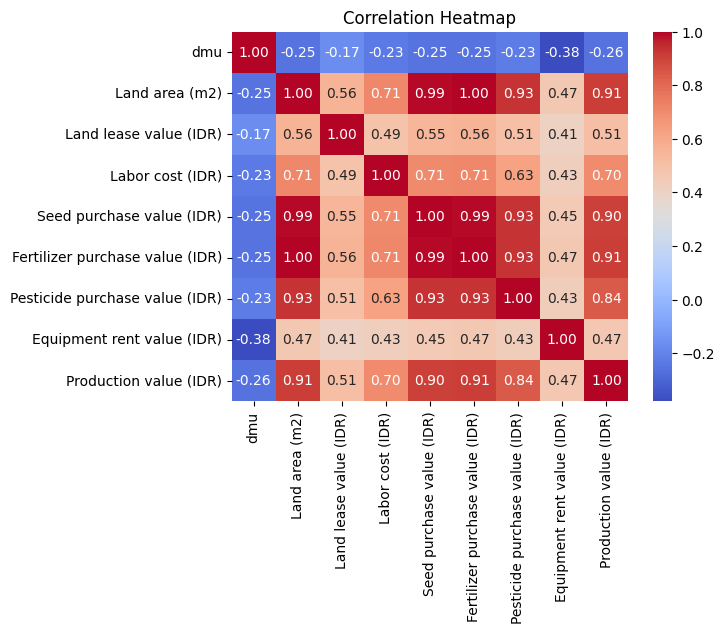

In [350]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_farmer = farmer.select_dtypes(include=[np.number])

# Compute the correlation matrix
corr = numeric_farmer.corr()

# Plot the heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


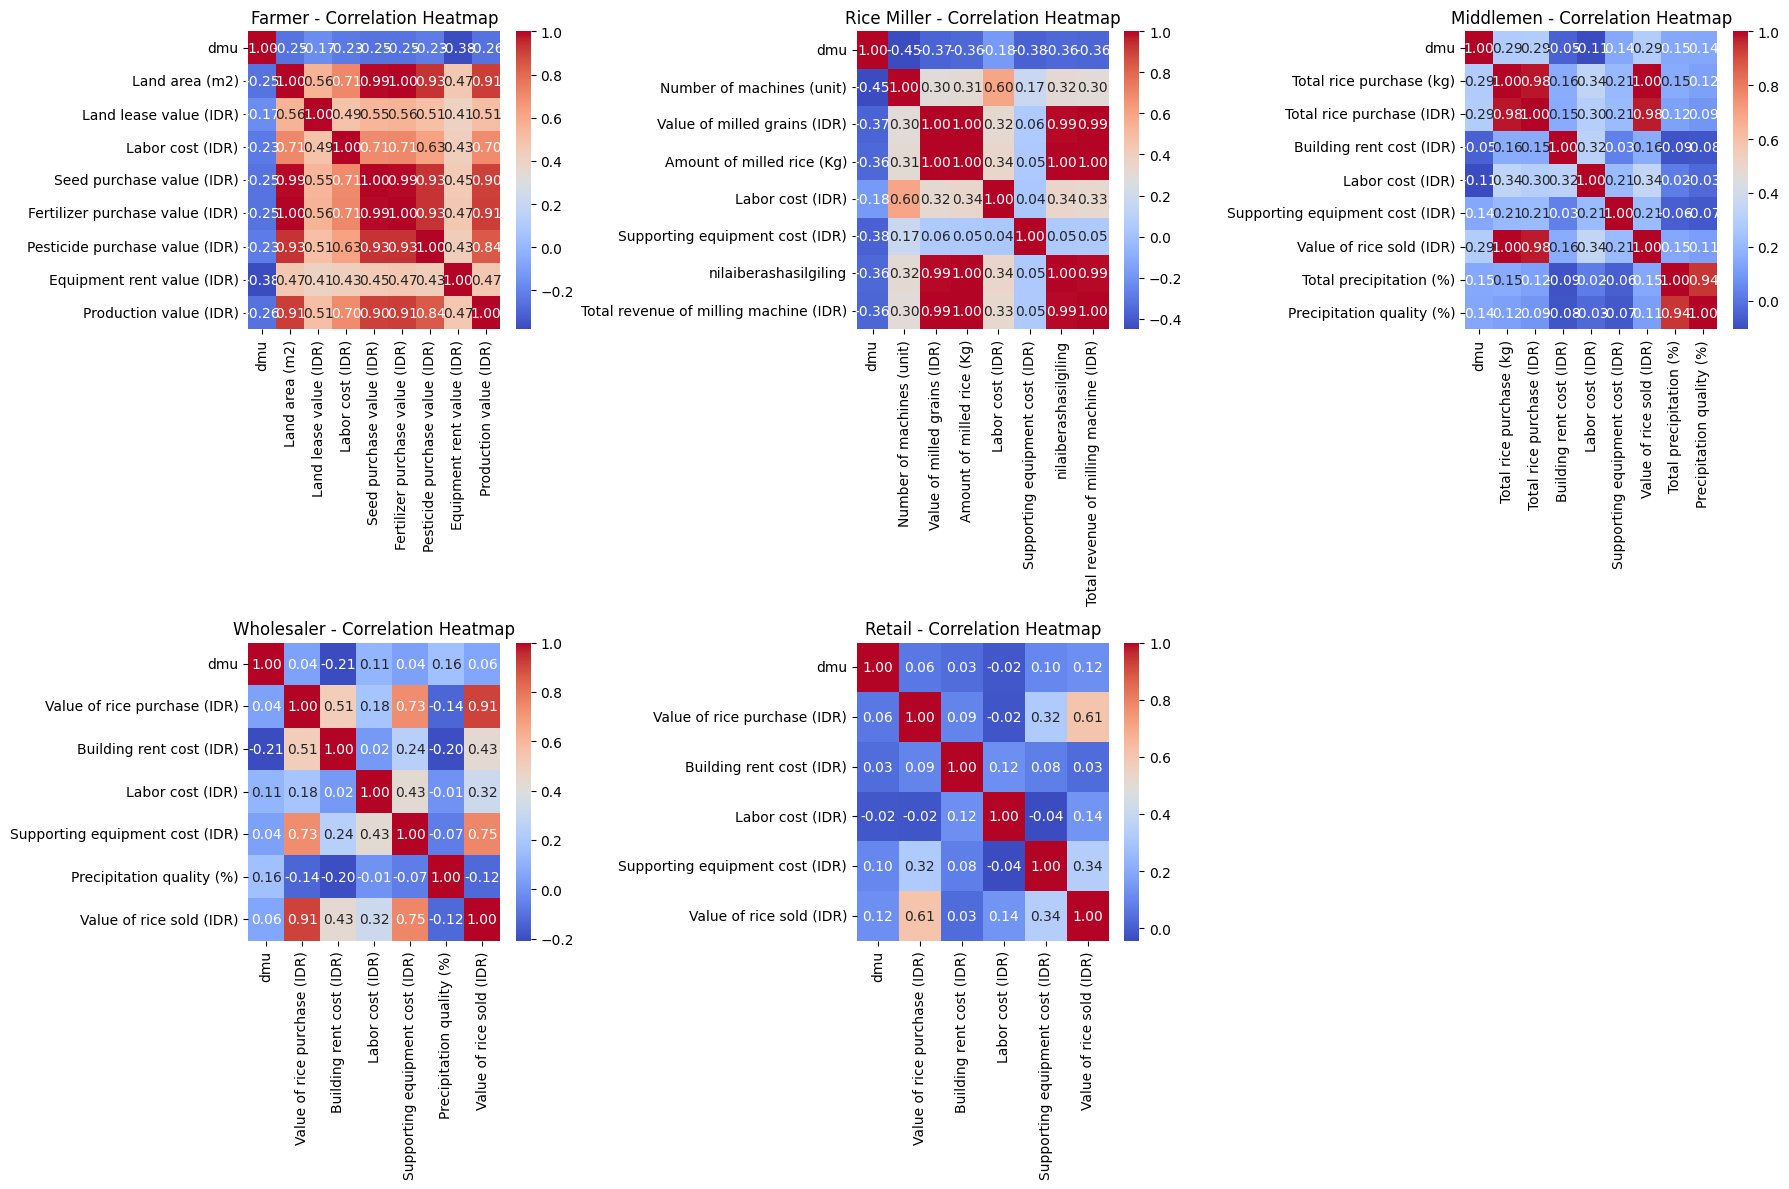

In [ ]:
dataframes = {
    'Farmer': farmer,
    'Rice Miller': rice_miller,
    'Middlemen': middlemen,
    'Wholesaler': wholesaler,
    'Retail': retail
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (name, df) in enumerate(dataframes.items()):
    numeric_df = df.select_dtypes(include=[np.number])
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[idx])
    axes[idx].set_title(f'{name} - Correlation Heatmap')

# Hide the extra subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

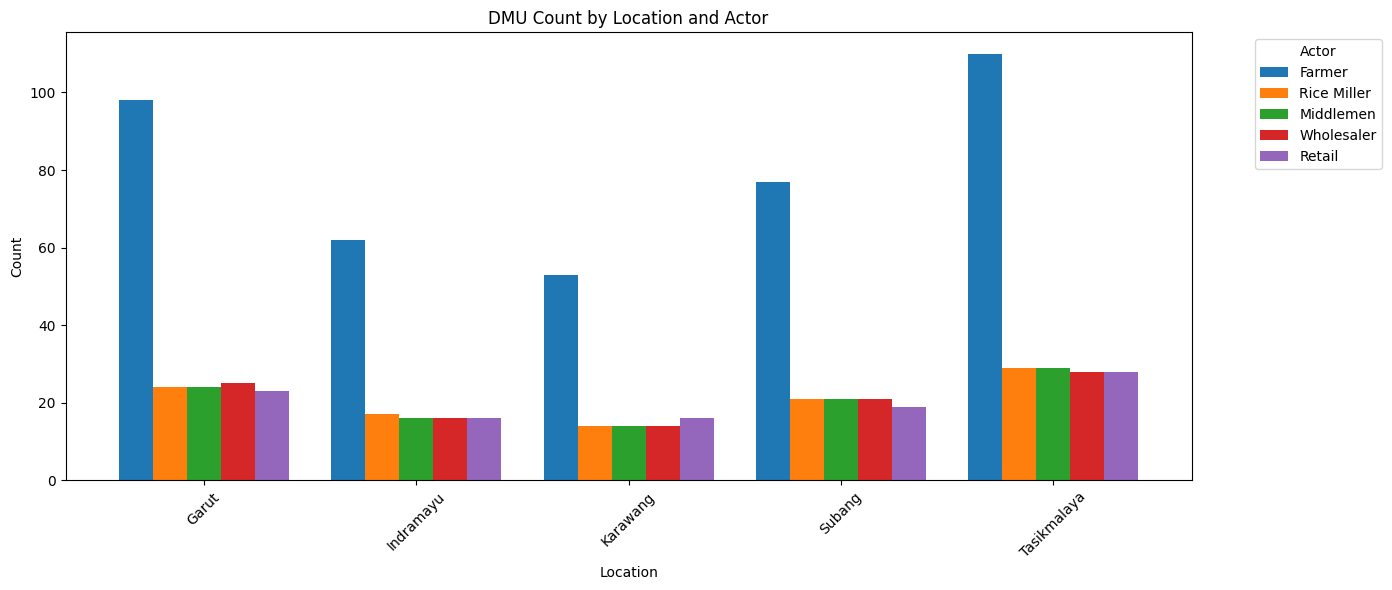

In [353]:
fig, axes = plt.subplots(1, 1, figsize=(14, 6))

# Create a dictionary to store counts for each location and actor
location_data = {}
for location in farmer['Location'].unique():
    location_data[location] = {}
    for name, df in dataframes.items():
        location_data[location][name] = len(df[df['Location'] == location])

# Convert to DataFrame for easier plotting
location_df = pd.DataFrame(location_data).T

# Plot grouped bar chart
location_df.plot(kind='bar', ax=axes, width=0.8)
axes.set_title('DMU Count by Location and Actor')
axes.set_xlabel('Location')
axes.set_ylabel('Count')
axes.legend(title='Actor', bbox_to_anchor=(1.05, 1), loc='upper left')
axes.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [381]:
print(farmer.groupby('Location')['Production value (IDR)'].mean())
print(rice_miller.groupby('Location')['Value of milled grains (IDR)'].mean())
print(rice_miller.groupby('Location')['nilaiberashasilgiling'].mean())
print(middlemen.groupby('Location')['Total rice purchase (IDR)'].mean())
print(middlemen.groupby('Location')['Value of rice sold (IDR)'].mean())
print(wholesaler.groupby('Location')['Value of rice purchase (IDR)'].mean())
print(wholesaler.groupby('Location')['Value of rice sold (IDR)'].mean())
print(retail.groupby('Location')['Value of rice purchase (IDR)'].mean())
print(retail.groupby('Location')['Value of rice sold (IDR)'].mean())

Location
Garut          1.874601e+07
Indramayu      5.574806e+07
Karawang       1.090048e+08
Subang         4.201941e+07
Tasikmalaya    2.020445e+07
Name: Production value (IDR), dtype: float64
Location
Garut          1.061021e+08
Indramayu      8.555159e+08
Karawang       1.556500e+08
Subang         2.005143e+08
Tasikmalaya    1.117659e+08
Name: Value of milled grains (IDR), dtype: float64
Location
Garut          1.271632e+08
Indramayu      1.046645e+09
Karawang       1.536759e+08
Subang         2.509387e+08
Tasikmalaya    1.219328e+08
Name: nilaiberashasilgiling, dtype: float64
Location
Garut          3.906833e+07
Indramayu      1.477344e+08
Karawang       7.542500e+07
Subang         1.247833e+08
Tasikmalaya    5.160522e+07
Name: Total rice purchase (IDR), dtype: float64
Location
Garut          3.885667e+07
Indramayu      1.805938e+08
Karawang       8.886071e+07
Subang         1.590848e+08
Tasikmalaya    5.214207e+07
Name: Value of rice sold (IDR), dtype: float64
Location
Garut      

In [380]:
retail

,dmu,Value of rice purchase (IDR),Building rent cost (IDR),Labor cost (IDR),Supporting equipment cost (IDR),Value of rice sold (IDR),Location
0,1,1375000.0,200000.0,3000000.0,150000.0,1750000.0,Garut
1,2,2700000.0,200000.0,3000000.0,200000.0,3500000.0,Garut
2,3,2700000.0,200000.0,3000000.0,200000.0,3500000.0,Garut
3,4,2695000.0,200000.0,3000000.0,30000.0,3000000.0,Garut
4,5,2612500.0,200000.0,3000000.0,300000.0,3500000.0,Garut
...,...,...,...,...,...,...,...
97,24,2695000.0,200000.0,3000000.0,150000.0,3520000.0,Tasikmalaya
98,25,2450000.0,150000.0,3000000.0,200000.0,2000000.0,Tasikmalaya
99,26,2850000.0,200000.0,400000.0,200000.0,2250000.0,Tasikmalaya
100,27,2250000.0,200000.0,2000000.0,500000.0,3000000.0,Tasikmalaya


Location
Garut          1.061021e+08
Indramayu      8.555159e+08
Karawang       1.556500e+08
Subang         2.005143e+08
Tasikmalaya    1.117659e+08
Name: Value of milled grains (IDR), dtype: float64
Location
Garut          1.271632e+08
Indramayu      1.046645e+09
Karawang       1.536759e+08
Subang         2.509387e+08
Tasikmalaya    1.219328e+08
Name: nilaiberashasilgiling, dtype: float64


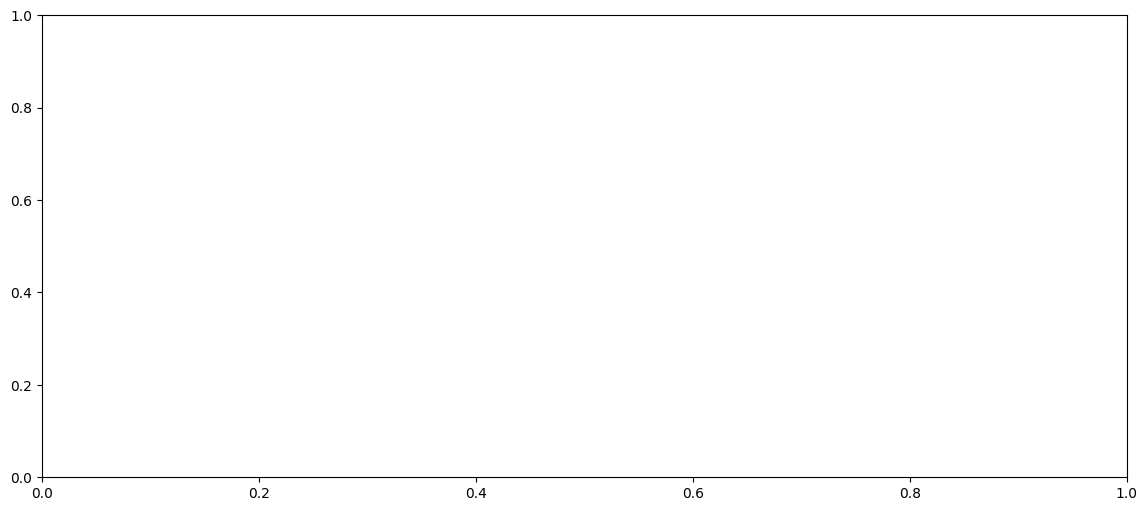

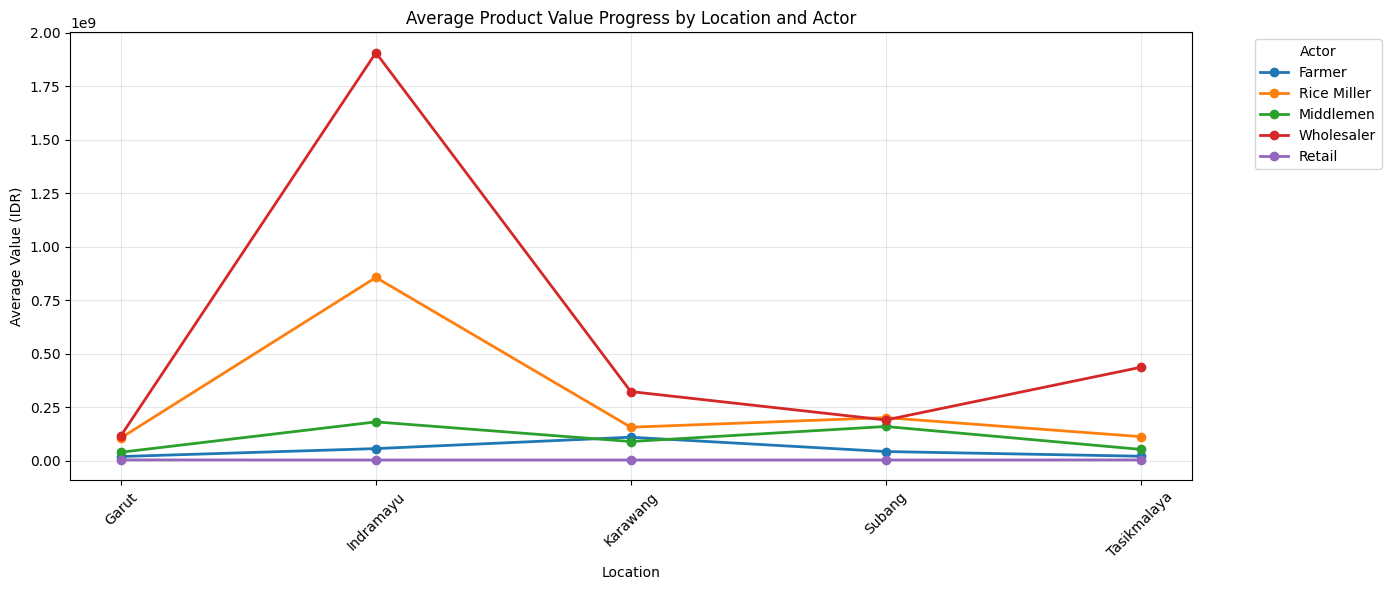

In [367]:
fig, axes = plt.subplots(1, 1, figsize=(14, 6))

# Create a dictionary to store average values for each location and actor
location_value_data = {}

# Get unique locations from farmer data
locations = farmer['Location'].unique()

for location in locations:
    location_value_data[location] = {}
    
    # Farmer: Production value
    farmer_loc = farmer[farmer['Location'] == location]
    location_value_data[location]['Farmer'] = farmer_loc['Production value (IDR)'].mean() if len(farmer_loc) > 0 else 0
    
    # Rice Miller: Value of milled grains (assuming a column with milled grains value)
    rice_miller_loc = rice_miller[rice_miller['Location'] == location]
    # Try to find relevant columns for rice miller
    rice_miller_value_cols = [col for col in rice_miller.columns if 'nilai' in col.lower() or 'value' in col.lower() or 'hasil' in col.lower()]
    if rice_miller_value_cols:
        location_value_data[location]['Rice Miller'] = rice_miller_loc[rice_miller_value_cols[0]].mean() if len(rice_miller_loc) > 0 else 0
    else:
        location_value_data[location]['Rice Miller'] = 0
    
    # Middlemen: Average of rice purchase and sold values
    middlemen_loc = middlemen[middlemen['Location'] == location]
    middlemen_value_cols = [col for col in middlemen.columns if 'nilai' in col.lower() or 'value' in col.lower()]
    if middlemen_value_cols and len(middlemen_loc) > 0:
        location_value_data[location]['Middlemen'] = middlemen_loc[middlemen_value_cols].mean().mean()
    else:
        location_value_data[location]['Middlemen'] = 0
    
    # Wholesaler: Average of rice purchase and sold values
    wholesaler_loc = wholesaler[wholesaler['Location'] == location]
    wholesaler_value_cols = [col for col in wholesaler.columns if 'nilai' in col.lower() or 'value' in col.lower()]
    if wholesaler_value_cols and len(wholesaler_loc) > 0:
        location_value_data[location]['Wholesaler'] = wholesaler_loc[wholesaler_value_cols].mean().mean()
    else:
        location_value_data[location]['Wholesaler'] = 0
    
    # Retail: Average of rice purchase and sold values
    retail_loc = retail[retail['Location'] == location]
    retail_value_cols = [col for col in retail.columns if 'nilai' in col.lower() or 'value' in col.lower()]
    if retail_value_cols and len(retail_loc) > 0:
        location_value_data[location]['Retail'] = retail_loc[retail_value_cols].mean().mean()
    else:
        location_value_data[location]['Retail'] = 0

# Convert to DataFrame for easier plotting
value_df = pd.DataFrame(location_value_data).T

# Plot line chart
fig, axes = plt.subplots(1, 1, figsize=(14, 6))
for actor in value_df.columns:
    axes.plot(value_df.index, value_df[actor], marker='o', label=actor, linewidth=2)

axes.set_title('Average Product Value Progress by Location and Actor')
axes.set_xlabel('Location')
axes.set_ylabel('Average Value (IDR)')
axes.legend(title='Actor', bbox_to_anchor=(1.05, 1), loc='upper left')
axes.grid(True, alpha=0.3)
plt.xticks(rotation=45)


plt.tight_layout()
plt.show()